In [2]:
#Important: cache directories must be set before imports
import os

os.environ["NUMBA_CACHE_DIR"] = "/nemo/lab/briscoej/home/users/boeziog/python_cache/numba"
os.environ["XDG_CACHE_HOME"]  = "/nemo/lab/briscoej/home/users/boeziog/python_cache"
os.environ["MPLCONFIGDIR"]    = "/nemo/lab/briscoej/home/users/boeziog/python_cache/matplotlib"

In [3]:
import scanpy as sc
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sclitr as sl
import igraph
sc.set_figure_params(dpi=100)
sns.set_style("ticks")

In [29]:
# ─── EXPERIMENT PARAMETERS — edit these before running ───────────────────────
tissue           = "NT"
injection_stage  = "HH16"
collection_stage = "HH31"

annotation_col    = "cell_type_final"   # column in adata.obs with cell type labels
leiden_resolution = 0.6

experiment_name = f"{tissue}_inj{injection_stage}_coll{collection_stage}"
print(f"Experiment:  {experiment_name}")
print(f"Annotation:  {annotation_col}")
print(f"Leiden res:  {leiden_resolution}")

Experiment:  NT_injHH16_collHH31
Annotation:  cell_type_final
Leiden res:  0.6


In [14]:
data_path = "/nemo/lab/briscoej/home/users/boeziog/LARRY/"

h5ad_path = os.path.join(
    data_path, "anndata",
    f"preprocessing_larry_chicken_{experiment_name}_annotated_withbarcodes.h5ad"
)

output_dir = os.path.join(data_path, "scLiTr", experiment_name)
os.makedirs(output_dir, exist_ok=True)

figures_output = os.path.join(
    data_path, "LARRY_spinal_cord", "Jupyter_notebooks",
    "plots", "chicken", "scLiTr", experiment_name
)
os.makedirs(figures_output, exist_ok=True)

res_tag = f"res{str(leiden_resolution).replace('.', '')}"

clones_path = os.path.join(output_dir, f"{res_tag}_clones_clone2vec.h5ad")
shap_path   = os.path.join(output_dir, f"{res_tag}_shapdata_c2v.h5ad")

def save_plot(plot_name, annotation=None):
    suffix = f"_{annotation}" if annotation is not None else ""
    filename = f"{res_tag}_{plot_name}{suffix}.pdf"
    save_path = os.path.join(figures_output, filename)
    plt.savefig(save_path, format="pdf", bbox_inches="tight")
    print(f"Saved: {save_path}")

# Load h5ad

In [15]:
adata = sc.read_h5ad(h5ad_path)
print(adata)
print(adata.obs.columns.tolist())

AnnData object with n_obs × n_vars = 20307 × 26117
    obs: 'sample_id', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'doublet_score', 'predicted_doublet', 'sample', 'cell_type_final', 'cell_barcode', 'clone'
    var: 'n_cells'
    uns: 'cell_type_final_colors', 'cluster_10', 'cluster_10_colors', 'cluster_12', 'cluster_14', 'cluster_16', 'cluster_18', 'cluster_2', 'cluster_20', 'cluster_22', 'cluster_24', 'cluster_26', 'cluster_28', 'cluster_28_colors', 'cluster_2_colors', 'cluster_30', 'cluster_32', 'cluster_34', 'cluster_36', 'cluster_38', 'cluster_4', 'cluster_40', 'cluster_42', 'cluster_44', 'cluster_46', 'cluster_48', 'cluster_48_colors', 'cluster_4_colors', 'cluster_50', 'cluster_52', 'cluster_54', 'cluster_54_colors', 'cluster_56', 'cluster_58', 'cluster_6', 'cluster_60', 'cluster_62', 'cluster_64', 'cluster_66', 'cluster_68', 'cluster_68_colors', 'cluster_6_colors', 'cluster_70', 'cluster_72', 'clust

In [16]:
# Expose annotation_col as 'cell_type' for downstream cells
if annotation_col != "cell_type":
    adata.obs["cell_type"] = adata.obs[annotation_col]

In [17]:
# Ensure 2D UMAP is available
if "X_umap_2d" not in adata.obsm:
    adata.obsm["X_umap_2d"] = adata.obsm["X_umap"][:, :2]

# scLiTr analyses

### Check the biggest clone

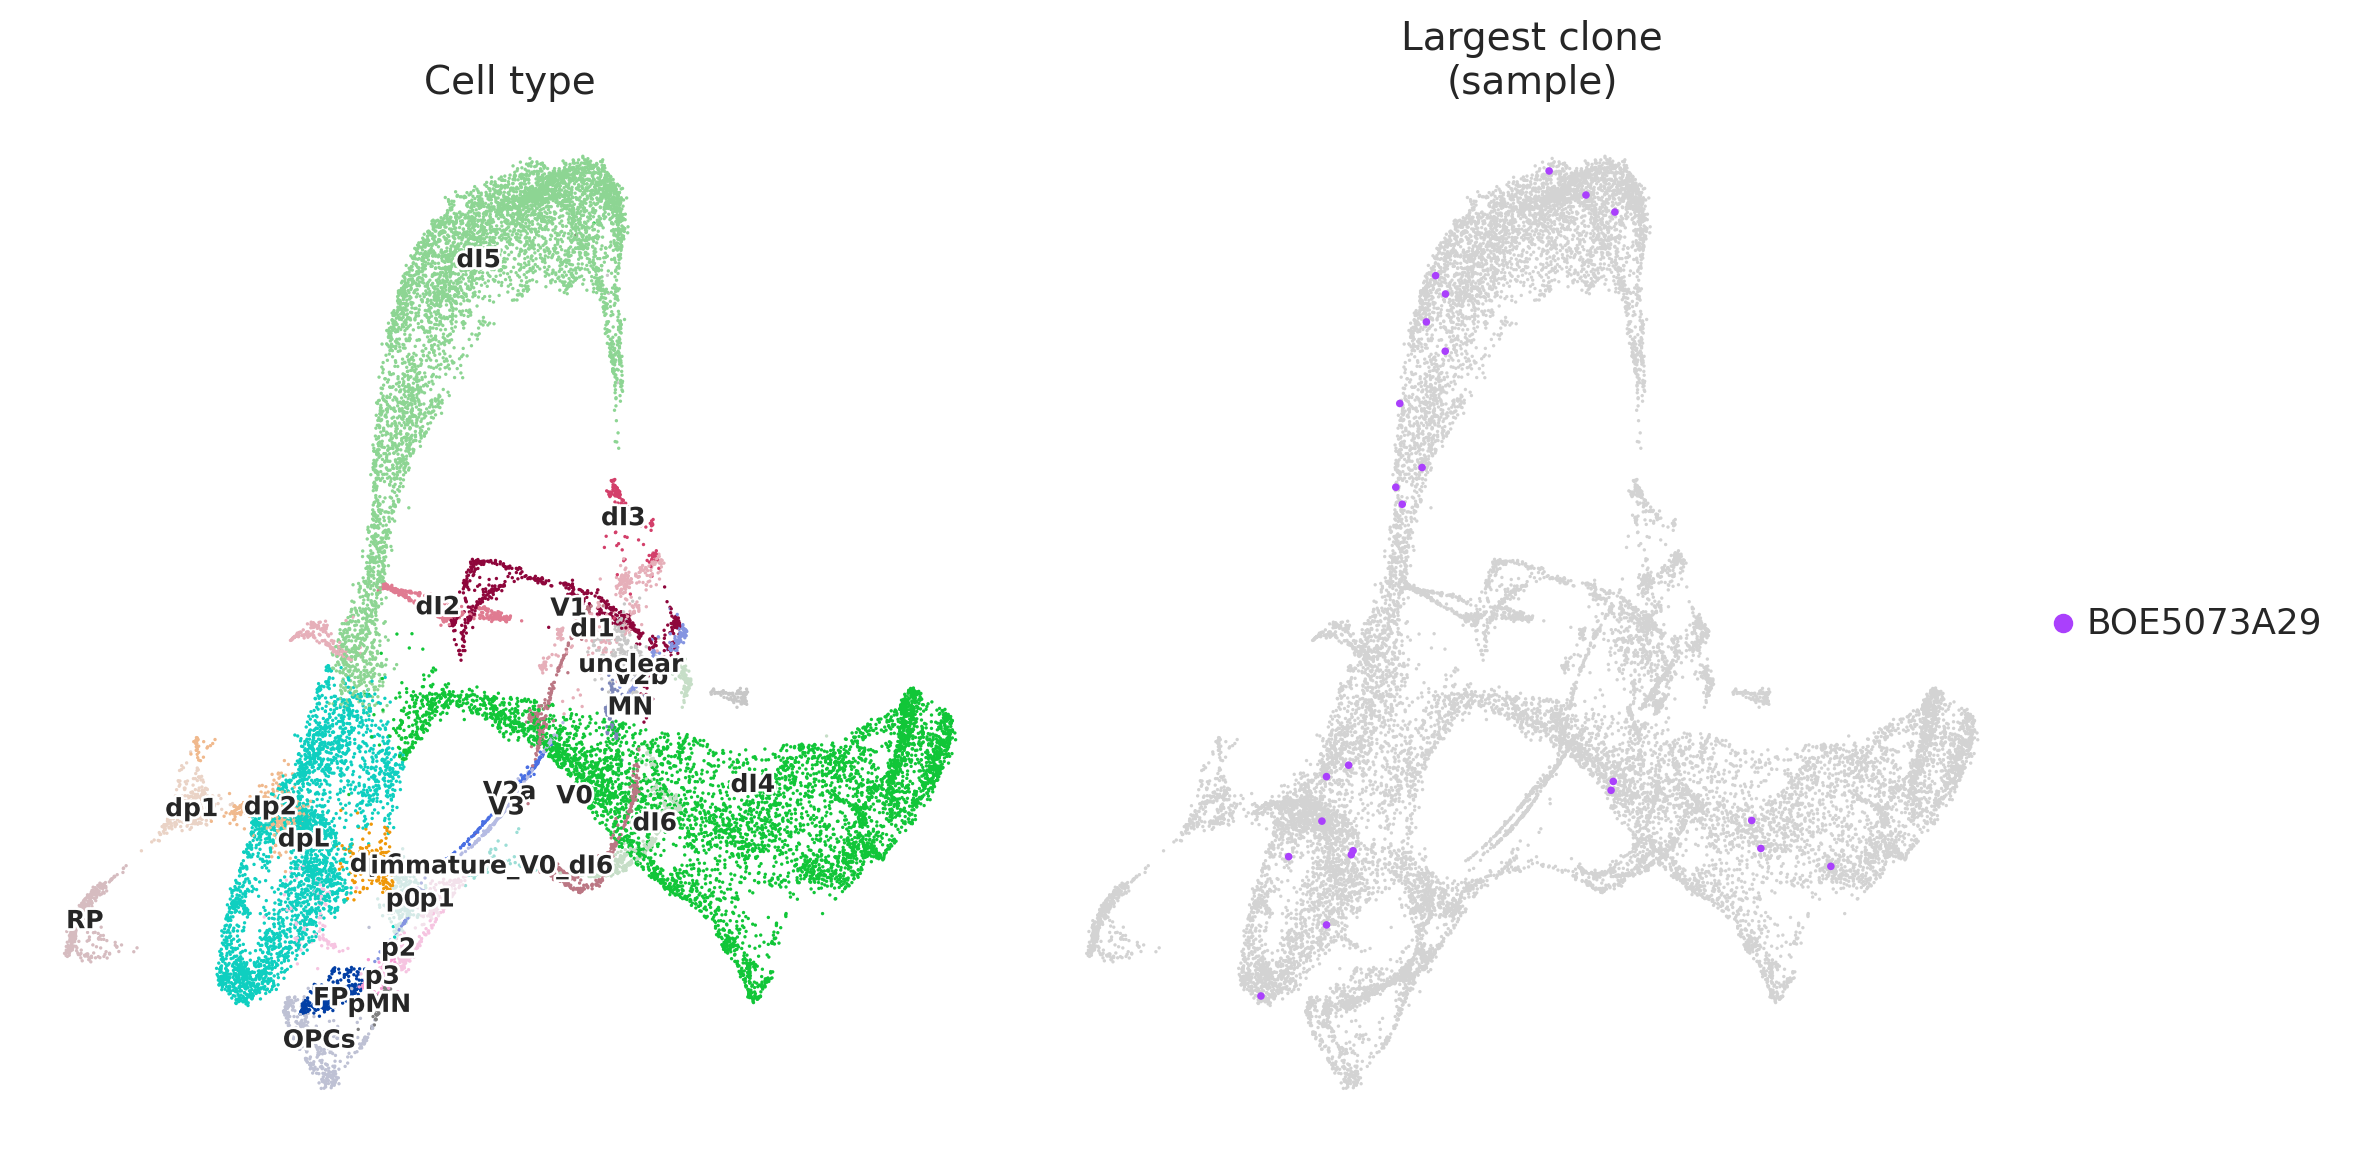

In [18]:
fig, axes = plt.subplots(ncols=2, figsize=(12, 6))

sc.pl.embedding(
    adata,
    basis="X_umap_2d",
    color="cell_type",
    frameon=False,
    title="Cell type",
    legend_loc="on data",
    legend_fontsize=9,
    legend_fontoutline=2,
    ax=axes[0],
    show=False,
)

sl.pl.clone(
    adata,
    clone_col="clone",
    clone_name=adata.obs["clone"].value_counts().index[0],
    basis="X_umap_2d",
    title="Largest clone",
    kwargs_clone={"color": "sample"},
    ax=axes[1],
)

fig.tight_layout()

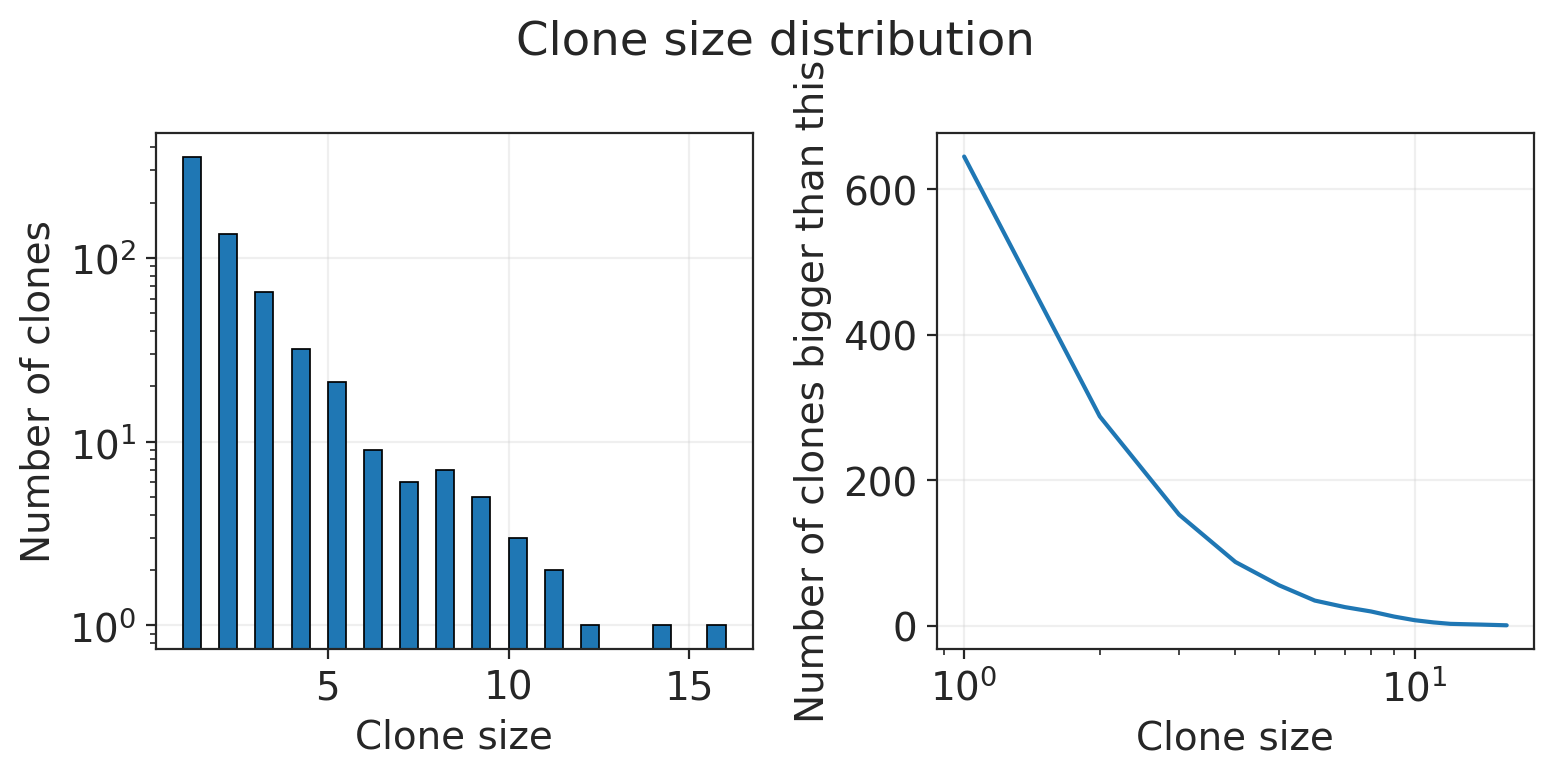

In [19]:
sl.pl.basic_stats(adata, obs_name="clone", title="Clone size distribution")

In [20]:
adata_clone2vec = adata[adata.obs["clone"].notna()].copy()

In [21]:
sl.tl.clonal_nn(
    adata_clone2vec,
    obs_name="clone",
    use_rep="X_scVI",
    min_size=2,
    tqdm_bar=True,
)

100%|██████████| 1370/1370 [00:00<00:00, 1386.51it/s]


In [22]:
clones = sl.tl.clone2vec(
    adata_clone2vec,
    obs_name="clone",
    fill_ct=None,
    device="cpu",
    n_epochs=100,
)

100%|██████████| 100/100 [49:13<00:00, 29.54s/it]
/camp/lab/briscoej/home/users/boeziog/.conda/envs/sclitr_cpu/lib/python3.9/site-packages/anndata/_core/storage.py:85: ImplicitModificationWarning: X should not be a np.matrix, use np.ndarray instead.
  warnings.warn(msg, ImplicitModificationWarning)
/camp/lab/briscoej/home/users/boeziog/.conda/envs/sclitr_cpu/lib/python3.9/site-packages/anndata/_core/storage.py:85: ImplicitModificationWarning: Layer 'frequencies' should not be a np.matrix, use np.ndarray instead.
  warnings.warn(msg, ImplicitModificationWarning)
/camp/lab/briscoej/home/users/boeziog/.conda/envs/sclitr_cpu/lib/python3.9/site-packages/anndata/_core/storage.py:85: ImplicitModificationWarning: Layer 'counts' should not be a np.matrix, use np.ndarray instead.
  warnings.warn(msg, ImplicitModificationWarning)


In [23]:
clones.write_h5ad(clones_path)
print(f"Saved clones to {clones_path}")

Saved clones to /nemo/lab/briscoej/home/users/boeziog/LARRY/scLiTr/NT_injHH16_collHH31/res05_clones_clone2vec.h5ad


In [ ]:
# Load clones if already computed
# clones = sc.read_h5ad(clones_path)
# print(f"Loaded clones from {clones_path}")

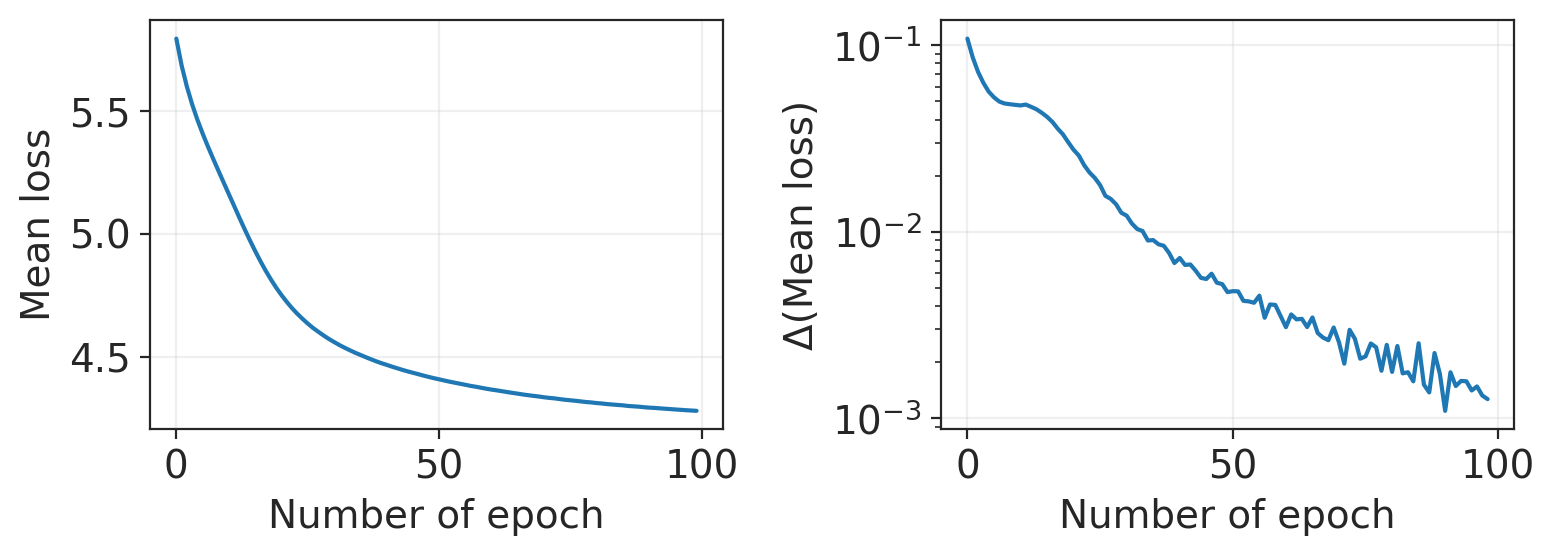

In [24]:
sl.pl.epochs_loss(clones)

Saved: /nemo/lab/briscoej/home/users/boeziog/LARRY/LARRY_spinal_cord/Jupyter_notebooks/plots/chicken/scLiTr/NT_injHH16_collHH31/res05_clonal_clusters_UMAP.pdf


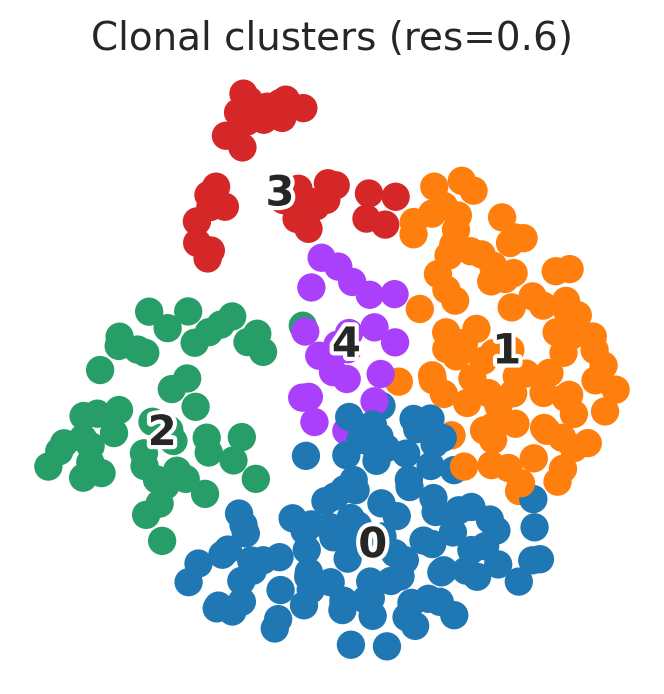

In [33]:
sc.pp.neighbors(clones, use_rep="clone2vec", n_neighbors=15)
sc.tl.umap(clones)
sc.tl.leiden(clones, resolution=leiden_resolution)

sc.pl.umap(
    clones,
    color="leiden",
    frameon=False,
    title=f"Clonal clusters (res={leiden_resolution})",
    legend_loc="on data",
    legend_fontsize=15,
    legend_fontoutline=3,
    show=False
)
save_plot("clonal_clusters_UMAP")

/tmp/slurm_47474024/ipykernel_3744310/3972190511.py:10: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata.obs["clonal_cluster_plot"] = adata.obs["clonal_cluster"].replace("NA", np.nan)


Saved: /nemo/lab/briscoej/home/users/boeziog/LARRY/LARRY_spinal_cord/Jupyter_notebooks/plots/chicken/scLiTr/NT_injHH16_collHH31/res05_cells_UMAP_and_clonal_clusters.pdf


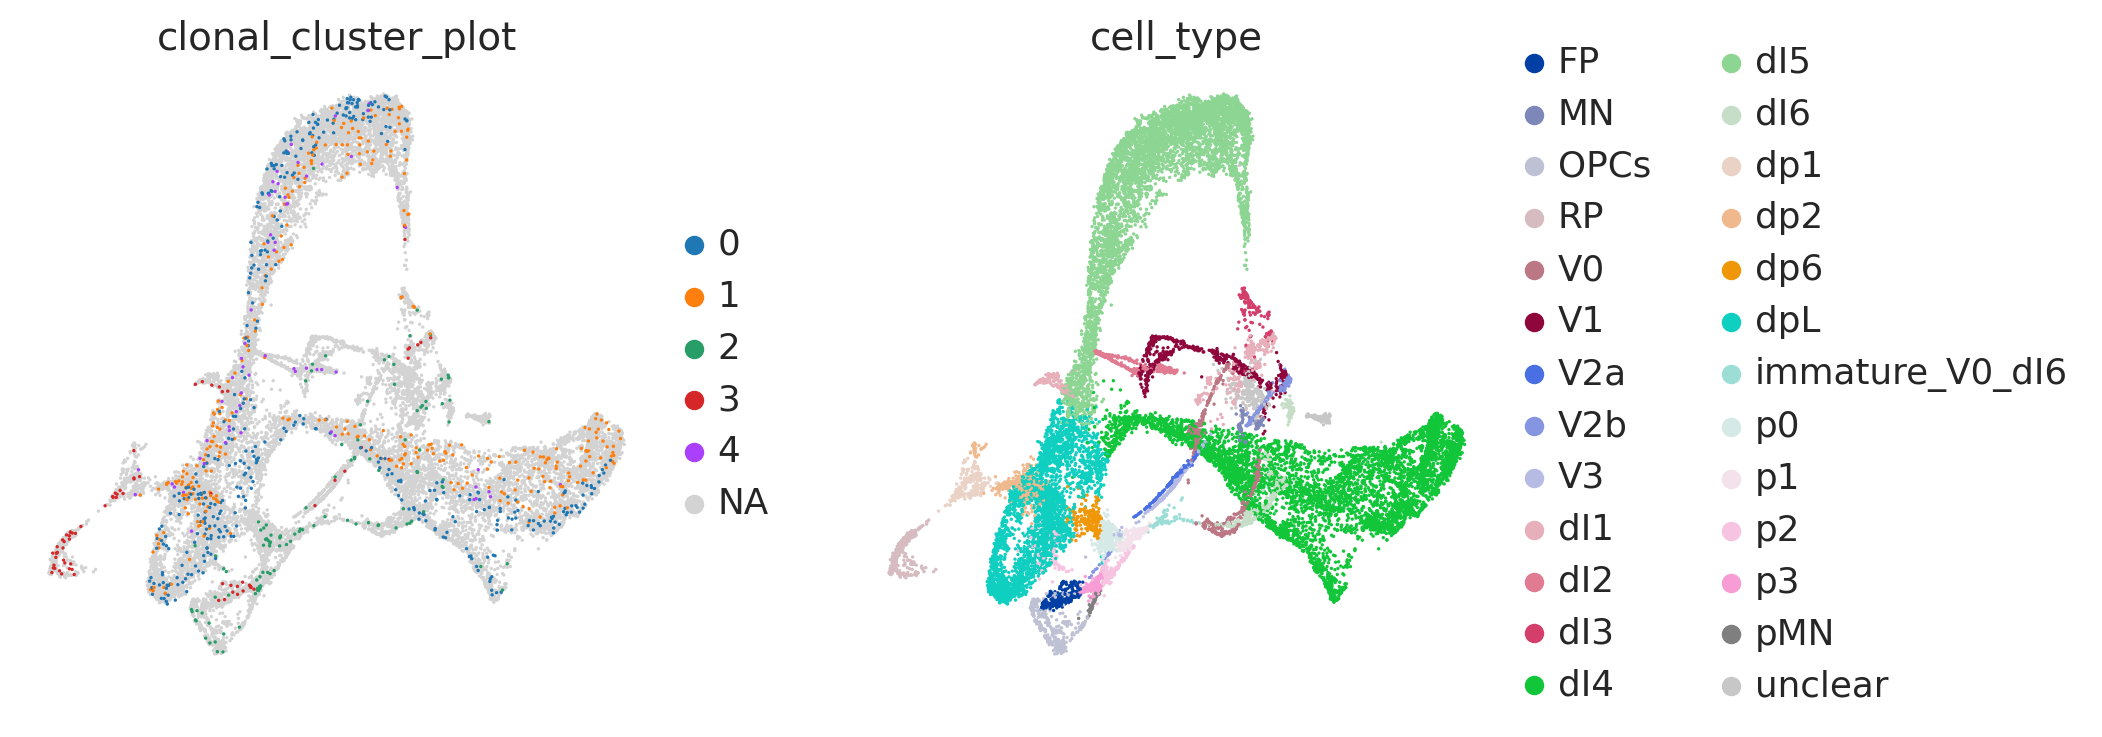

In [34]:
sl.tl.transfer_clonal_annotation(
    adata,
    clones,
    adata_clone_name="clone",
    adata_obs_name="clonal_cluster",
    clones_obs_name="leiden",
    fill_values="NA",
)

adata.obs["clonal_cluster_plot"] = adata.obs["clonal_cluster"].replace("NA", np.nan)

sc.pl.embedding(
    adata,
    basis="X_umap_2d",
    color=["clonal_cluster_plot", "cell_type"],
    frameon=False,
    ncols=2,
    show=False
)
save_plot("cells_UMAP_and_clonal_clusters")

In [35]:
# Auto-derive cluster list; edit manually if you want a specific order
clusters = sorted(clones.obs["leiden"].unique(), key=lambda x: int(x))
print("Clonal clusters:", clusters)

Clonal clusters: ['0', '1', '2', '3', '4']


Saved: /nemo/lab/briscoej/home/users/boeziog/LARRY/LARRY_spinal_cord/Jupyter_notebooks/plots/chicken/scLiTr/NT_injHH16_collHH31/res05_clonal_clusters_density_on_cells_UMAP.pdf


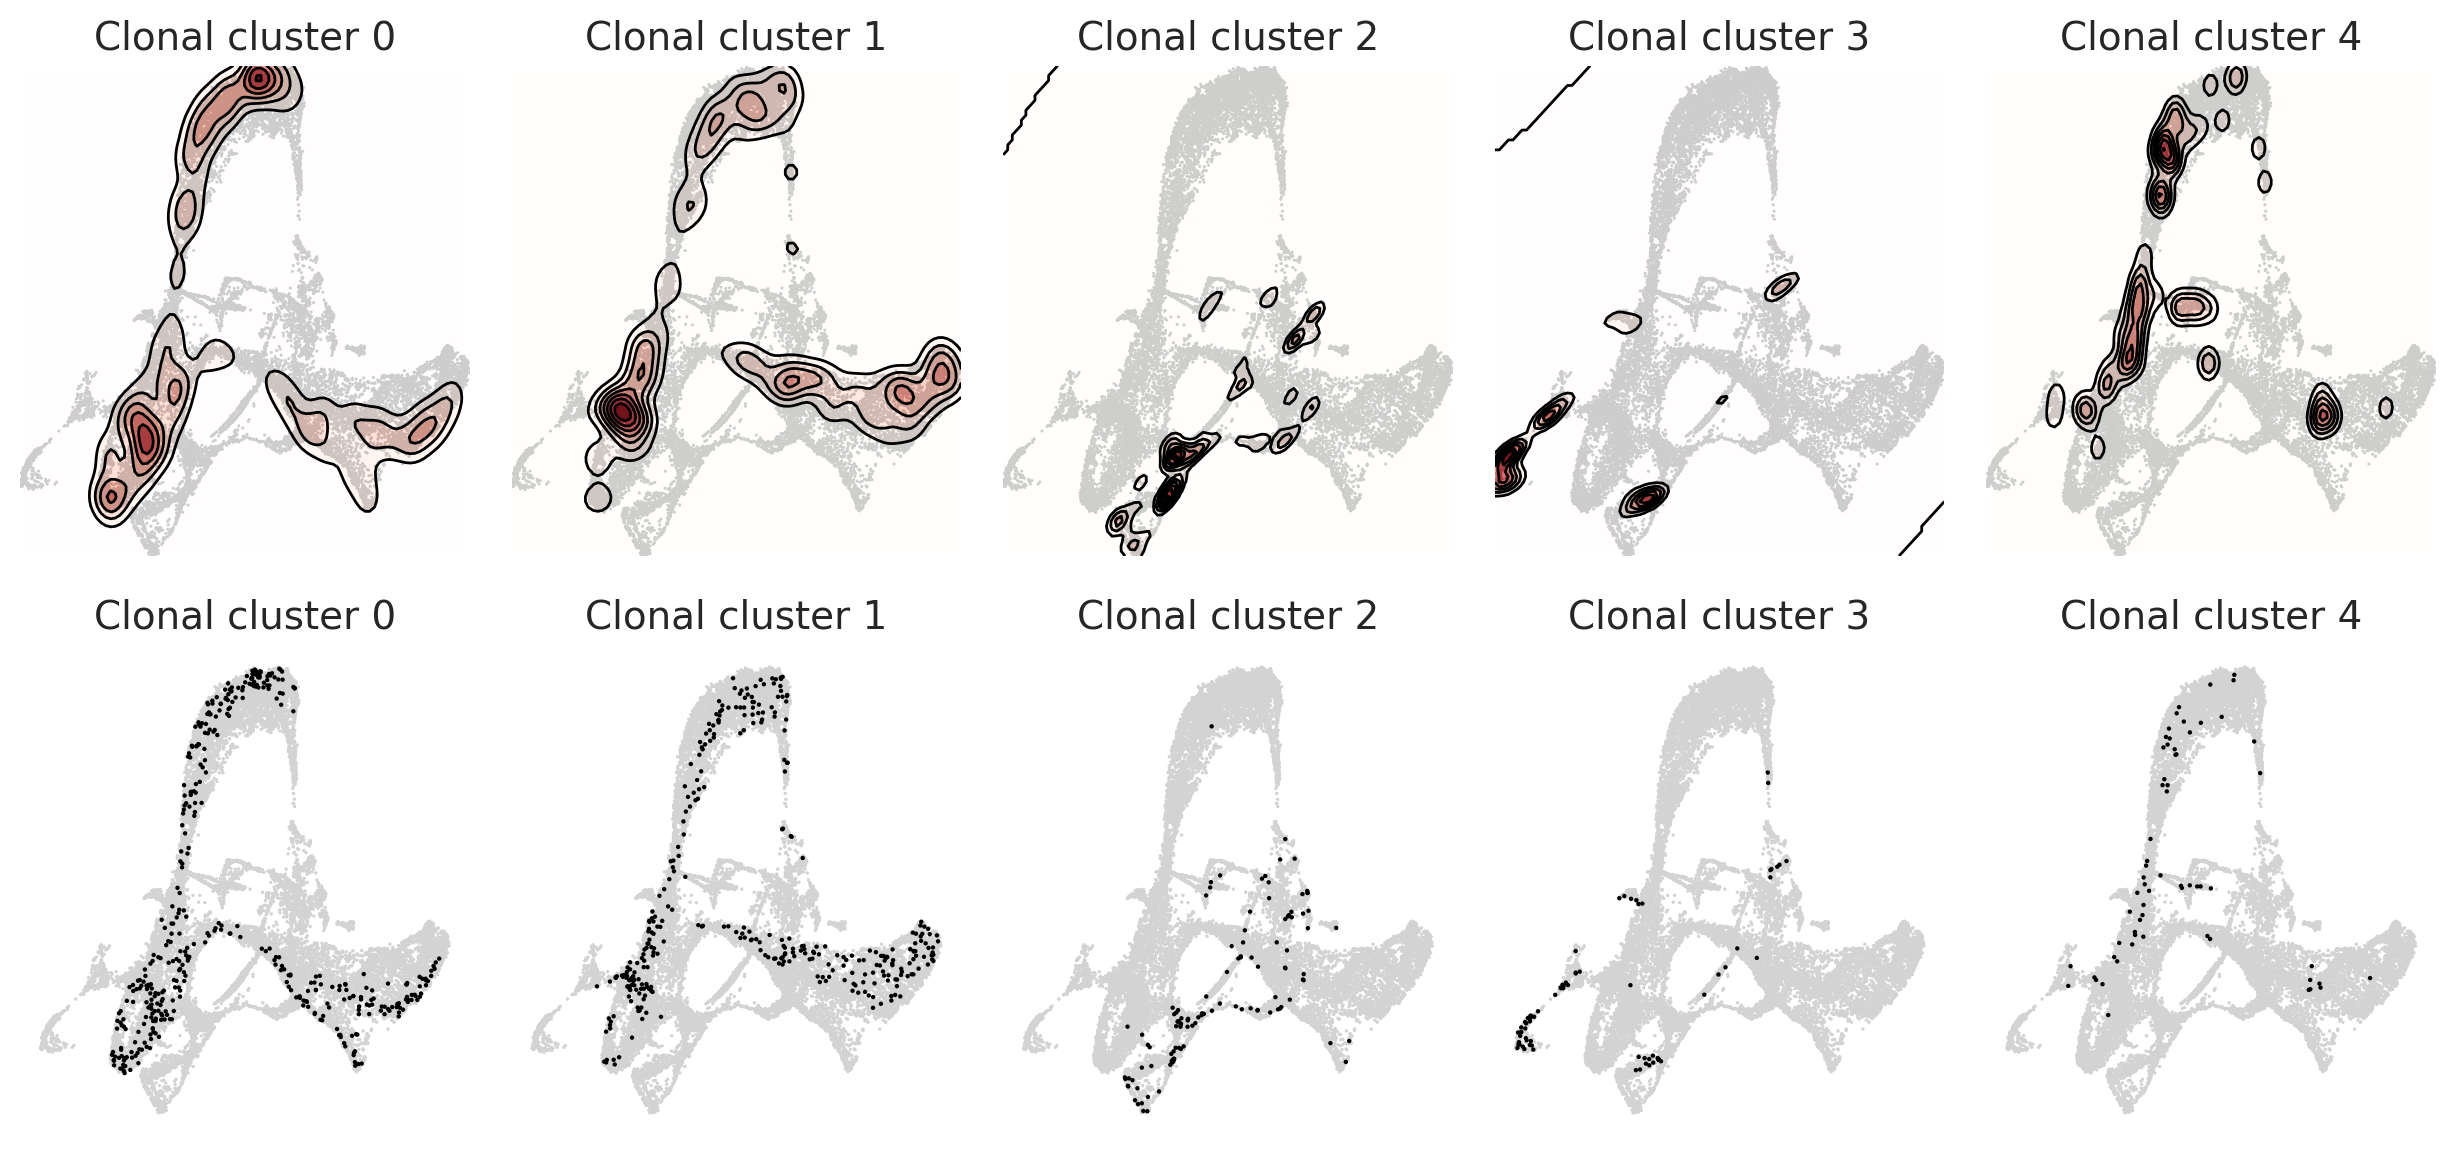

In [36]:
n_clusters = len(clusters)

fig, axes = plt.subplots(
    nrows=2,
    ncols=n_clusters,
    figsize=(2.5 * n_clusters, 6),
)

for i, clonal_cluster in enumerate(clusters):
    sl.pl.kde(
        adata,
        basis="X_umap_2d",
        groupby="clonal_cluster",
        group=clonal_cluster,
        title=f"Clonal cluster {clonal_cluster}",
        ax=axes[0, i],
    )
    sl.pl.clone(
        adata,
        clone_col="clonal_cluster",
        clone_name=clonal_cluster,
        basis="X_umap_2d",
        title=f"Clonal cluster {clonal_cluster}",
        s=10,
        ax=axes[1, i],
    )

save_plot("clonal_clusters_density_on_cells_UMAP")
fig.tight_layout()

# Bar plots clonal clusters

## Cell types

Saved: /nemo/lab/briscoej/home/users/boeziog/LARRY/LARRY_spinal_cord/Jupyter_notebooks/plots/chicken/scLiTr/NT_injHH16_collHH31/res05_clonal_cluster_barplot_cell_type.pdf


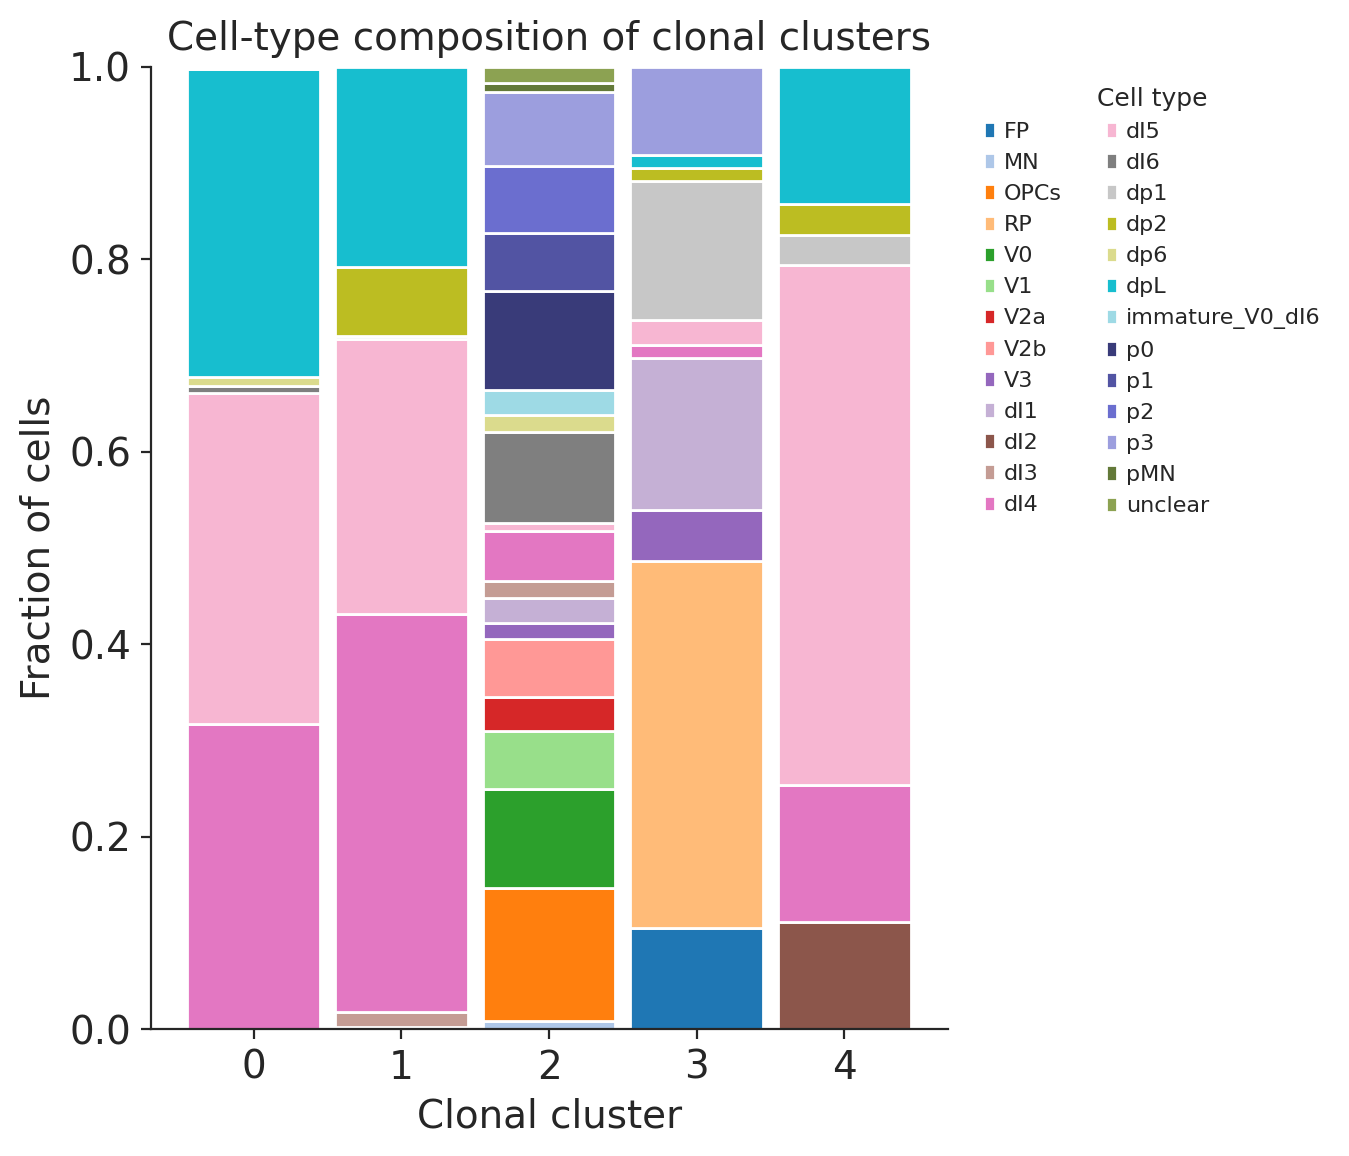

In [37]:
excluded_cell_types = {"Immature neurons", "immature neurons", "Unknown"}

df_plot = adata.obs.loc[
    adata.obs["clonal_cluster"].notna() &
    (adata.obs["clonal_cluster"] != "NA") &
    adata.obs["cell_type"].notna() &
    ~adata.obs["cell_type"].isin(excluded_cell_types),
    ["clonal_cluster", "cell_type"]
].copy()
df_plot["clonal_cluster"] = df_plot["clonal_cluster"].astype(str)

counts = (
    df_plot
    .groupby(["clonal_cluster", "cell_type"], observed=True)
    .size()
    .reset_index(name="n_cells")
)

plot_df = (
    counts
    .groupby(["clonal_cluster", "cell_type"], observed=True)["n_cells"]
    .sum()
    .groupby(level=0)
    .apply(lambda x: x / x.sum())
    .unstack(fill_value=0)
)
plot_df = plot_df.loc[plot_df.sum(axis=1) > 0]

palette = (
    sns.color_palette("tab20", 20) +
    sns.color_palette("tab20b", 20) +
    sns.color_palette("tab20c", 20)
)[:plot_df.shape[1]]

fig, ax = plt.subplots(figsize=(1.4 * plot_df.shape[0], 6))
plot_df.plot(kind="bar", stacked=True, ax=ax, color=palette, width=0.9)

ax.set_xticks(range(len(plot_df)))
ax.set_xticklabels(plot_df.index.get_level_values(0).astype(str), rotation=0)
ax.set_ylim(0, 1)
ax.set_ylabel("Fraction of cells")
ax.set_xlabel("Clonal cluster")
ax.set_title("Cell-type composition of clonal clusters")
ax.legend(
    title="Cell type",
    bbox_to_anchor=(1.02, 1), loc="upper left",
    frameon=False, fontsize=8, title_fontsize=9, ncol=2
)
save_plot("clonal_cluster_barplot", annotation="cell_type")
sns.despine()
plt.tight_layout()
plt.show()

## Lineage subdivisions

In [39]:
# ── Update this map to match the cell types in your experiment ────────────────
lineage_subdivision_map = {
    "FP": "Sub_1",
    "V3": "Sub_1",
    "p3": "Sub_1",

    "MN": "Sub_2",
    "OPCs": "Sub_2",
    "V2a": "Sub_2",
    "V2b": "Sub_2",
    "p2": "Sub_2",
    "pMN": "Sub_2",

    "V0": "Sub_3",
    "V1": "Sub_3",
    "dI6": "Sub_3",
    "dp6": "Sub_3",
    "p0": "Sub_3",
    "p1": "Sub_3",
    "Immature V0-dI6-V1": "Sub_3",

    "dI3": "Sub_4",
    "dI4_dILA": "Sub_4",
    "dI5_dILB": "Sub_4",
    "dpL": "Sub_4",

    "RP": "Sub_5",
    "dI1": "Sub_5",
    "dI2": "Sub_5",
    "dp1_2": "Sub_5",
}

adata.obs["lineage_subdivision"] = adata.obs["cell_type"].map(lineage_subdivision_map)
print(adata.obs["lineage_subdivision"].value_counts(dropna=False))

lineage_subdivision
NaN      11707
Sub_4     3170
Sub_3     2161
Sub_5     1227
Sub_2     1214
Sub_1      828
Name: count, dtype: int64


Saved: /nemo/lab/briscoej/home/users/boeziog/LARRY/LARRY_spinal_cord/Jupyter_notebooks/plots/chicken/scLiTr/NT_injHH16_collHH31/res05_clonal_cluster_barplot_lineage_subdivisions.pdf


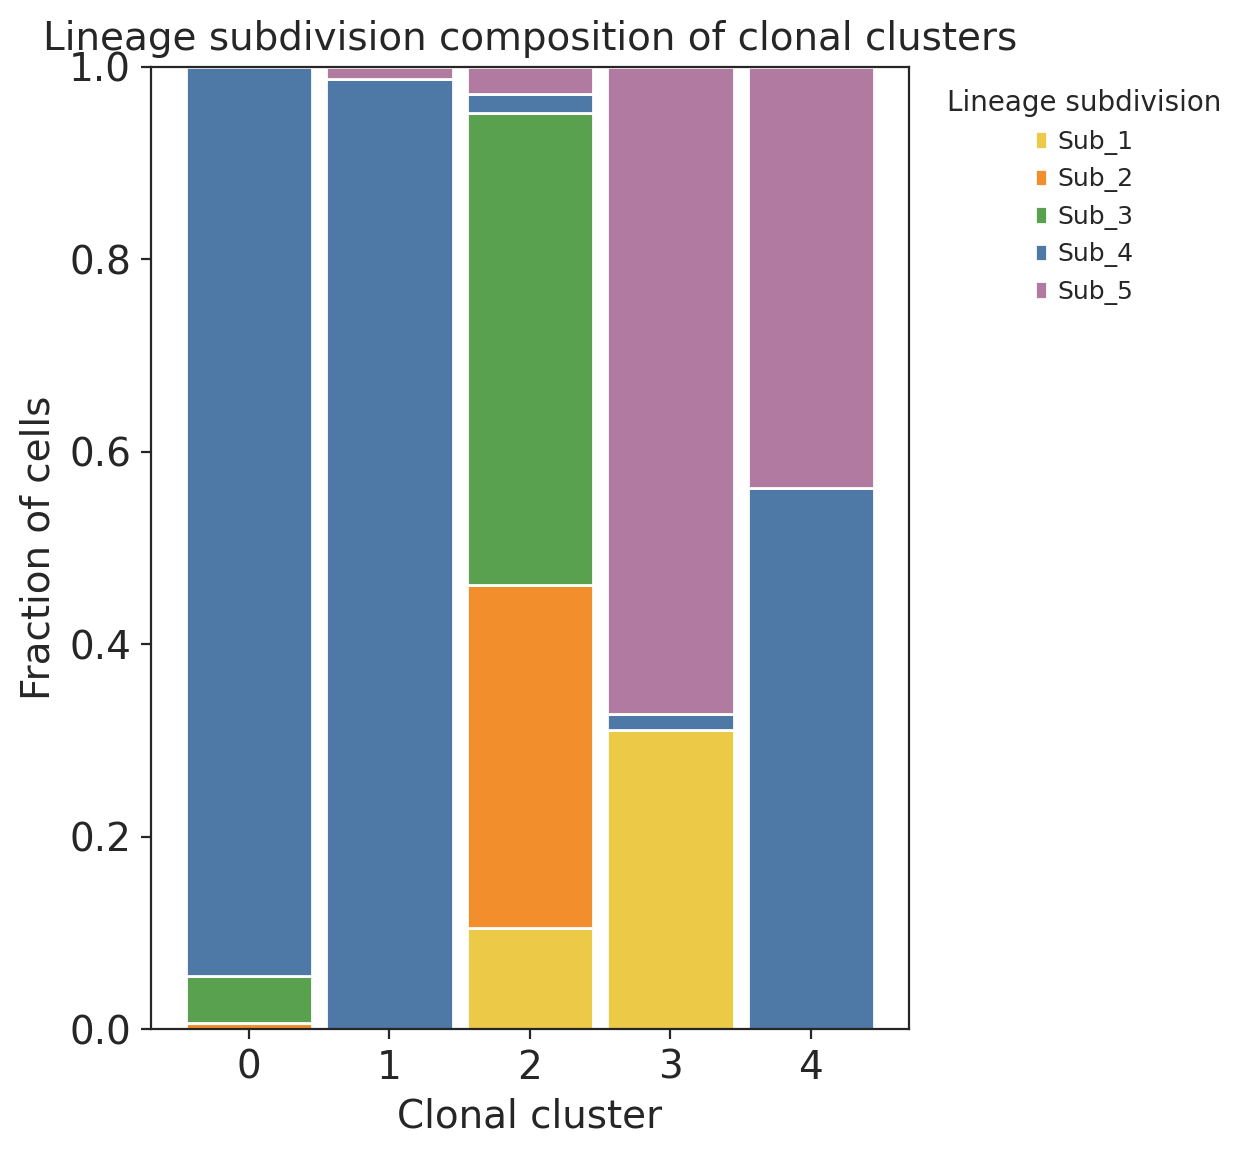

In [40]:
df_plot = adata.obs.loc[
    adata.obs["clonal_cluster"].notna() &
    (adata.obs["clonal_cluster"] != "NA") &
    ~adata.obs["cell_type"].isin(excluded_cell_types) &
    adata.obs["lineage_subdivision"].notna(),
    ["clonal_cluster", "lineage_subdivision"]
].copy()

counts = (
    df_plot
    .groupby(["clonal_cluster", "lineage_subdivision"], observed=True)
    .size()
    .reset_index(name="n_cells")
)

plot_df = (
    counts
    .pivot_table(
        index="clonal_cluster",
        columns="lineage_subdivision",
        values="n_cells",
        fill_value=0,
        observed=True
    )
)
plot_df = plot_df.div(plot_df.sum(axis=1), axis=0)

sub_palette = {
    "Sub_1": "#EDC948",
    "Sub_2": "#F28E2B",
    "Sub_3": "#59A14F",
    "Sub_4": "#4E79A7",
    "Sub_5": "#B07AA1",
}

# cluster_order is auto-derived; edit manually if you want a specific order
cluster_order = sorted(plot_df.index.tolist(), key=lambda x: int(x))
plot_df = plot_df.reindex(cluster_order).dropna(how="all")

fig, ax = plt.subplots(figsize=(1.3 * plot_df.shape[0], 6))
plot_df.plot(
    kind="bar", stacked=True, ax=ax,
    color=[sub_palette[c] for c in plot_df.columns], width=0.9
)
ax.set_ylim(0, 1)
ax.set_ylabel("Fraction of cells")
ax.set_xlabel("Clonal cluster")
ax.set_title("Lineage subdivision composition of clonal clusters")
ax.set_xticks(range(len(plot_df)))
ax.set_xticklabels(plot_df.index.astype(str), rotation=0)
ax.legend(
    title="Lineage subdivision",
    bbox_to_anchor=(1.02, 1), loc="upper left",
    frameon=False, fontsize=9, title_fontsize=10
)
save_plot("clonal_cluster_barplot", annotation="lineage_subdivisions")
plt.tight_layout()
plt.show()

# Heatmap

In [41]:
# ── USER CHOICES ──────────────────────────────────────────────────────────────
ANNOTATION = "lineage_subdivision"   # or "cell_type"

# cluster_order: auto-derived below; override here if needed
# cluster_order = ["2", "0", "3", "1", "4"]

cell_type_order = [
    "RP", "dp1_2", "dI1", "dI2", "dI3",
    "dpL", "dI4_dILA", "dI5_dILB",
    "dI6", "dp6",
    "p0", "V0", "p1", "V1",
    "V2a", "V2b", "p2", "OPCs", "pMN", "MN",
    "p3", "V3", "FP",
]

lineage_sub_order = ["Sub_5", "Sub_4", "Sub_3", "Sub_2", "Sub_1"]

excluded_cell_types = {"Immature neurons", "immature neurons", "Unknown"}

In [42]:
df = adata.obs.loc[
    adata.obs["clonal_cluster"].notna() &
    (adata.obs["clonal_cluster"] != "NA"),
    ["clonal_cluster", ANNOTATION]
].copy()

if ANNOTATION == "cell_type":
    df = df[~df["cell_type"].isin(excluded_cell_types)]

counts = (
    df
    .groupby(["clonal_cluster", ANNOTATION], observed=True)
    .size()
    .reset_index(name="n_cells")
)

heatmap_df = (
    counts
    .groupby(["clonal_cluster", ANNOTATION], observed=True)["n_cells"]
    .sum()
    .groupby(level=0)
    .apply(lambda x: x / x.sum())
    .unstack(fill_value=0)
)

cluster_order = sorted(heatmap_df.index.get_level_values(0).tolist(),
                       key=lambda x: int(x) if str(x).isdigit() else x)
heatmap_df = heatmap_df.loc[[c for c in cluster_order if c in heatmap_df.index]]

if ANNOTATION == "cell_type":
    heatmap_df = heatmap_df.reindex(
        columns=[ct for ct in cell_type_order if ct in heatmap_df.columns], fill_value=0
    )
    vmax = 0.2
elif ANNOTATION == "lineage_subdivision":
    heatmap_df = heatmap_df.reindex(
        columns=[s for s in lineage_sub_order if s in heatmap_df.columns], fill_value=0
    )
    vmax = None

plt.figure(figsize=(0.5 * heatmap_df.shape[1] + 3, 4))
sns.heatmap(
    heatmap_df, vmax=vmax, cmap="OrRd",
    linewidths=0.5, linecolor="white",
    cbar_kws={"label": "Fraction of cells"}
)
ax = plt.gca()
ax.set_yticks(range(len(heatmap_df.index)))
ax.set_yticklabels(heatmap_df.index.get_level_values(0).astype(str), rotation=0)
plt.xlabel(ANNOTATION.replace("_", " ").title())
plt.ylabel("Clonal cluster")
plt.title("Clonal cluster composition")
save_plot("clonal_cluster_heatmap_OrRd", annotation=ANNOTATION)
plt.tight_layout()
plt.show()

/tmp/slurm_47474024/ipykernel_3744310/3785002082.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts


ValueError: invalid literal for int() with base 10: 'NA'

# Analysis of fate commitment predictors

In [ ]:
# ── Define progenitor cell types — update to match your experiment ────────────
progenitors = [
    "FP", "RP", "dI6", "dp1_2", "dp6", "dpL",
    "p0", "p1", "p2", "p3", "pMN"
]

adata.obs["early_state"] = np.where(
    adata.obs["cell_type"].isin(progenitors), "Early", "Other"
)
print(adata.obs["early_state"].value_counts())

In [ ]:
adata_clonal = adata[adata.obs["clone"].notna()].copy()
print(adata_clonal.obs["early_state"].value_counts())

## SHAP — clone2vec model

In [ ]:
shapdata_c2v = sl.tl.predict_c2v(
    adata_clonal,
    clones,
    clone_col="clone",
    ct_col="early_state",
    use_gpu=False,
    verbose=False,
    limit_ct="Early",
    use_ct=False,
    pseudobulk=True,
)

shapdata_c2v.write_h5ad(shap_path)
print(f"Saved SHAP data to {shap_path}")

In [ ]:
# Load SHAP data if already computed
shapdata_c2v = sc.read_h5ad(shap_path)

In [ ]:
shapdata_c2v.var["average_shap"] = (
    shapdata_c2v.layers["shap"].mean(axis=0).A[0]
)
shapdata_c2v.var["average_shap_normalized"] = (
    shapdata_c2v.var["average_shap"] /
    shapdata_c2v.var["average_shap"].max()
)

shapdata_c2v.var.sort_values("average_shap", ascending=False).head(20)

### Validate model fit

In [ ]:
clones_predicted = clones.copy()
clones_predicted = clones_predicted[clones.uns["clone2vec_predicted_names"]]
clones_predicted.obsm["clone2vec"] = clones.uns["clone2vec_predicted"].copy()
clones_predicted = clones_predicted[
    clones_predicted.obs["eval_set"] == "validation"
].copy()

clones_validation = clones[clones.obs["eval_set"] == "validation"].copy()

sc.pp.neighbors(clones_predicted, use_rep="clone2vec", n_neighbors=15)
sc.tl.umap(clones_predicted)
sc.pp.neighbors(clones_validation, use_rep="clone2vec", n_neighbors=15)
sc.tl.umap(clones_validation)

fig, axes = plt.subplots(ncols=2, figsize=(8, 4))
sc.pl.umap(clones_predicted, ax=axes[0], show=False, frameon=False,
           title="Predicted clone2vec", color="leiden", legend_loc="on data")
sc.pl.umap(clones_validation, ax=axes[1], show=False, frameon=False,
           title="Real clone2vec", color="leiden", legend_loc="on data")
plt.tight_layout()

In [ ]:
from scipy.stats import pearsonr

common_clones = clones_predicted.obs_names[
    clones_predicted.obs_names.isin(clones_validation.obs_names)
]
n_dims = clones_validation.obsm["clone2vec"].shape[1]

fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(15, 6))
row, col = 0, 0
for i in range(min(10, n_dims)):
    ax = axes[row, col]
    x = clones_predicted[common_clones].obsm["clone2vec"][:, i]
    y = clones_validation[common_clones].obsm["clone2vec"][:, i]
    sns.regplot(x=x, y=y,
                scatter_kws={"s": 10, "color": "grey"},
                line_kws={"color": sns.color_palette()[3]}, ax=ax)
    r = np.round(pearsonr(x, y)[0], 3)
    ax.set_title(f"Dim {i} (r = {r})")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Real")
    ax.grid(alpha=0.3)
    col += 1
    if col == 5:
        col, row = 0, row + 1
plt.tight_layout()

### SHAP biological interpretation

In [ ]:
c2v_df = pd.DataFrame(
    clones.obsm["clone2vec"],
    index=clones.obs_names
)
c2v_df["cluster"] = clones.obs["leiden"]
cluster_means = c2v_df.groupby("cluster").mean()

sns.heatmap(cluster_means, cmap="RdBu_r", center=0)
plt.ylabel("Clonal clusters")
plt.xlabel("Clone2vec dimension")
plt.title("Clonal clusters vs clone2vec dimensions")
save_plot("clonal_cluster_vs_dimension")
plt.tight_layout()
plt.show()

In [ ]:
all_top_genes = []
for dim in range(10):
    layer_name = f"shap_c2v{dim}"
    scores = np.array(shapdata_c2v.layers[layer_name].mean(axis=0)).flatten()
    gene_df = shapdata_c2v.var.copy()
    gene_df["score"] = scores
    gene_df["dimension"] = dim
    gene_df["gene"] = gene_df.index
    all_top_genes.append(
        gene_df.sort_values("score", ascending=False).head(20)[["dimension", "gene", "score"]]
    )

all_top_genes_df = pd.concat(all_top_genes, ignore_index=True)

top_genes_path = os.path.join(output_dir, f"{res_tag}_top_genes_per_dimension.csv")
all_top_genes_df.to_csv(top_genes_path, index=False)
print(f"Saved: {top_genes_path}")

all_top_genes_df.head(30)